# Module 6 — Data Understanding

**Objective:** Build a first-pass understanding of both raw datasets —
their shape, structure, data types, and quality signals — before any
cleaning or transformation happens.

In [2]:
import sys
from pathlib import Path

# Add project root to the path so we can import from src/
sys.path.append(str(Path.cwd().parent))

from src.data_loader import load_individual_data, load_sme_data

import pandas as pd
pd.set_option('display.max_columns', 50)

In [3]:
individual_df = load_individual_data(sample=True)
sme_df = load_sme_data()

Loaded individual data: loan_sample.csv -> shape (10000, 145)
Loaded SME data: shape (7805, 25)


## 6.1 Individual Borrower Dataset (LendingClub)

In [4]:
individual_df.shape

(10000, 145)

In [5]:
individual_df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,16000,16000,16000.0,36 months,9.49,512.46,B,B2,Informatics Specialist 1,10+ years,MORTGAGE,48880.0,Source Verified,Aug-2016,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,558xx,MN,22.91,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,16400,16400,16400.0,60 months,14.49,385.78,C,C4,Welder,2 years,MORTGAGE,41600.0,Verified,Aug-2016,Charged Off,n,NaN,NaN,debt_consolidation,Debt consolidation,562xx,MN,24.09,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,6000,6000,6000.0,36 months,19.03,220.03,D,D3,Meteorologist,4 years,RENT,67000.0,Verified,Aug-2017,Fully Paid,n,NaN,NaN,debt_consolidation,Debt consolidation,123xx,NY,21.98,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,6500,6500,6500.0,36 months,8.39,204.86,B,B1,Mobile Building Engineer,3 years,RENT,48000.0,Source Verified,Feb-2016,Fully Paid,n,NaN,NaN,credit_card,Credit card refinancing,328xx,FL,10.03,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,21000,21000,21000.0,60 months,17.97,532.92,D,D4,Properties,10+ years,RENT,92000.0,Source Verified,Jan-2016,Charged Off,n,NaN,NaN,debt_consolidation,Debt consolidation,554xx,MN,27.05,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
individual_df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
9995,NaN,NaN,35000,35000,35000.0,60 months,14.07,815.66,C,C3,Multi Store Manager,10+ years,MORTGAGE,60000.0,Verified,Mar-2018,Current,n,NaN,NaN,credit_card,Credit card refinancing,161xx,PA,22.83,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9996,NaN,NaN,35000,35000,34975.0,36 months,11.53,1154.66,B,B5,"Vice President, Technology",< 1 year,RENT,100000.0,Verified,Aug-2015,Fully Paid,n,NaN,NaN,credit_card,Credit card refinancing,941xx,CA,10.20,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9997,NaN,NaN,14000,14000,14000.0,60 months,15.02,333.21,C,C3,Cashier,10+ years,OWN,50000.0,Not Verified,Nov-2018,Current,n,NaN,NaN,other,Other,201xx,VA,32.72,...,0.0,33.0,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9998,NaN,NaN,6025,6025,5950.0,36 months,15.61,210.67,D,D1,lab tech,10+ years,MORTGAGE,51000.0,Source Verified,Oct-2015,Fully Paid,n,NaN,NaN,debt_consolidation,Debt consolidation,023xx,MA,13.65,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9999,NaN,NaN,10000,10000,10000.0,36 months,19.53,369.25,D,D5,Analyst,10+ years,MORTGAGE,83000.0,Source Verified,Apr-2016,Charged Off,n,NaN,NaN,debt_consolidation,NaN,480xx,MI,39.02,...,NaN,NaN,N,INTEREST ONLY-3 MONTHS DEFERRAL,EXCESSIVE_OBLIGATIONS,COMPLETED,3.0,84.32,Jan-2018,Apr-2018,Jan-2018,3.0,17.0,Late (16-30 days),252.96,5316.19,134.73,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
individual_df.dtypes.value_counts()

float64    105
str         36
int64        4
Name: count, dtype: int64

In [8]:
individual_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), str(36)
memory usage: 12.7 MB


In [9]:
individual_df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,0.0,9995.000000,9999.000000,9999.000000,4879.000000,1546.000000,9999.000000,9999.000000,10000.000000,9989.000000,9999.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,9999.000000,9.700000e+03,9780.000000,9780.000000,9700.000000,505.000000,505.000000,505.000000,505.000000,498.000000,505.000000,505.000000,505.000000,505.000000,171.000000,52.0,52.000000,52.0,52.000000,35.000000,52.000000,52.000000,165.000000,165.000000,165.000000
mean,NaN,NaN,15012.227500,15004.535000,14990.368998,13.098359,443.923403,7.837855e+04,NaN,18.924193,0.312131,0.569557,34.663251,71.767141,11.659966,0.195220,16830.337100,50.489538,24.268527,4433.66027,4432.722650,11843.759487,11830.481042,9324.519837,2381.277159,...,0.046805,1.783242e+05,50442.743354,23394.969325,43159.314124,35129.265347,0.625743,1.623762,11.108911,59.755020,2.782178,12.758416,0.041584,0.085149,36.707602,3.0,155.782115,3.0,14.000000,449.752286,11527.481731,154.577885,4913.623576,48.201333,12.775758
std,NaN,NaN,9295.325531,9293.417856,9296.682536,4.822646,267.214344,9.455436e+04,NaN,17.800073,0.883199,0.876864,22.214171,26.891610,5.773080,0.587845,22356.764123,24.716899,12.322726,7556.22562,7555.501751,10027.934886,10026.170805,8452.600087,2662.469142,...,0.399802,1.767831e+05,48081.355180,23230.477803,43752.665106,29088.871685,1.008166,1.816216,6.514789,25.611254,2.798823,8.278693,0.275042,0.381462,23.483083,0.0,139.962596,0.0,8.708797,356.699161,9007.022776,166.478566,3660.369599,8.146958,7.616055
min,NaN,NaN,1000.000000,1000.000000,216.295596,5.310000,30.460000,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.430000,3.0,0.000000,34.290000,1182.040000,0.150000,121.910000,25.940000,0.000000
25%,NaN,NaN,8000.000000,8000.000000,8000.000000,9.670000,249.045000,4.600000e+04,NaN,11.760000,0.000000,0.000000,16.000000,54.000000,8.000000,0.000000,6088.500000,31.600000,15.000000,0.00000,0.000000,4153.965000,4137.927500,2701.050000,687.815000,...,0.000000,5.042250e+04,20484.250000,8300.000000,14735.750000,15818.000000,0.000000,0.000000,7.000000,41.250000,1.000000,7.000000,0.000000,0.000000,17.500000,3.0,58.007500,3.0,8.000000,181.890000,4153.655000,34.700000,2047.540000,45.000000,6.000000
50%,NaN,NaN,12600.000000,12562.500000,12537.500000,12.620000,377.805000,6.500000e+04,NaN,17.800000,0.000000,0.000000,31.000000,74.000000,11.000000,0.000000,11516.500000,50.500000,22.000000,0.00000,0.000000,9050.823192,9031.805000,6600.555000,1479.540000,...,0.000000,1.148815e+05,37947.500000,16500.000000,32487.500000,27366.000000,0.000000,1.000000,10.000000,61.500000,2.000000,11.000000,0.000000,0.000000,35.000000,3.0,105.490000,3.0,15.500000,326.610000,9247.650000,92.305000,4173.000000,45.010000,14.000000
75%,NaN,NaN,20000.000000,20000.000000,20000.000000,15.990000,595.287500,9.420000e+04,NaN,24.545000,

## 6.2 SME Borrower Dataset (Corporate Credit Ratings)

In [10]:
sme_df.shape

(7805, 25)

In [11]:
sme_df.head()

,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,Long-term Debt / Capital,Debt/Equity Ratio,Gross Margin,Operating Margin,EBIT Margin,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,0.4551,0.8847,77.6230,19.4839,19.4839,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,0.0072,0.0073,43.6619,19.8327,19.8327,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,0.2924,0.4255,11.9008,3.3173,3.3173,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,0.4708,0.9491,64.5096,18.4549,18.4549,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,0.2644,0.4036,3.8385,1.3269,1.3269,1.5847,1.2304,0.6518,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


In [12]:
sme_df.tail()

,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,Long-term Debt / Capital,Debt/Equity Ratio,Gross Margin,Operating Margin,EBIT Margin,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
7800,Moody's Investors Service,"eBay, Inc.",BBB+,2016-02-22,1065088,1,7370.0,BusEq,EBAY,3.4927,0.5065,1.0263,79.3878,25.5703,25.5703,33.5661,28.0028,20.0768,0.4839,29.6077,95.6757,10.9659,14.6116,-1.2323,-1.2826
7801,Moody's Investors Service,"eBay, Inc.",BBB+,2016-03-02,1065088,1,7370.0,BusEq,EBAY,3.4927,0.5065,1.0263,79.3878,25.5703,25.5703,33.5661,28.0028,20.0768,0.4839,29.6077,95.6757,10.9659,14.6116,-1.2323,-1.2826
7802,Standard & Poor's Ratings Services,iHeartCommunications Inc.,CC,2016-03-08,739708,0,4832.0,Telcm,CCU,1.7606,0.1034,0.1523,54.2787,14.2454,14.2454,14.2454,12.7232,8.0626,0.8218,11.8335,13.5108,7.7070,10.6101,0.0907,1.2552
7803,Standard & Poor's Ratings Services,iHeartCommunications Inc.,CCC,2016-03-24,739708,0,4832.0,Telcm,CCU,1.7606,0.1034,0.1523,54.2787,14.2454,14.2454,14.2454,12.7232,8.0626,0.8218,11.8335,13.5108,7.7070,10.6101,0.0907,1.2552
7804,Standard & Poor's Ratings Services,iHeartCommunications Inc.,CC,2016-06-14,739708,0,4832.0,Telcm,CCU,1.7606,0.1034,0.1523,54.2787,14.2454,14.2454,14.2454,12.7232,8.0626,0.8218,11.8335,13.5108,7.7070,10.6101,0.0907,1.2552


In [13]:
sme_df.dtypes.value_counts()

float64    17
str         6
int64       2
Name: count, dtype: int64

In [14]:
sme_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   str    
 1   Corporation                    7805 non-null   str    
 2   Rating                         7805 non-null   str    
 3   Rating Date                    7805 non-null   str    
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   float64
 7   Sector                         7805 non-null   str    
 8   Ticker                         7805 non-null   str    
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   float64
 13 

In [15]:
sme_df.describe()

,CIK,Binary Rating,SIC Code,Current Ratio,Long-term Debt / Capital,Debt/Equity Ratio,Gross Margin,Operating Margin,EBIT Margin,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
count,7.805000e+03,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000
mean,7.371616e+05,0.653299,4052.576810,1.926313,0.452804,0.177349,42.433909,11.531612,11.582683,20.071493,8.659944,5.995566,0.849843,15.950507,21.481589,4.575705,7.076084,0.479756,0.119491
std,5.143542e+05,0.475950,1870.848802,1.921651,2.629158,34.456334,23.742020,25.469044,25.483934,24.380407,27.866408,24.055577,0.696204,230.592526,462.734075,9.229899,24.382027,6.050626,7.253660
min,1.750000e+03,0.000000,100.000000,0.174900,-86.363600,-1473.098000,-87.684000,-461.787800,-461.787800,-360.816900,-476.010000,-414.824800,0.068400,-11258.210000,-14023.260000,-226.442500,-745.454500,-91.330200,-130.665800
25%,9.355600e+04,0.000000,2834.000000,1.077300,0.286500,0.419700,22.453900,6.098200,6.181100,11.162100,4.008700,2.637100,0.399500,6.022800,-12.233900,2.391900,3.692600,-0.448500,-0.723700
50%,8.795260e+05,1.000000,3714.000000,1.496800,0.427200,0.752800,39.635400,12.120100,12.155800,18.304500,9.705100,6.938900,0.661200,12.500000,10.564100,4.767500,7.440800,0.237800,0.133500
75%,1.091587e+06,1.000000,4931.000000,2.161000,0.542200,1.211600,59.641700,19.464600,19.539900,30.661600,16.676900,12.366700,1.038800,20.515700,26.894100,7.881300,12.515100,1.088800,0.997800
max,1.748790e+06,1.000000,9997.000000,34.076800,171.500000,194.375000,100.000000,93.993000,93.993000,286.493500,221.289400,219.390300,8.503900,7038.461000,9882.979000,114.716900,466.666700,282.192100,107.737700


## 6.3 Building the Data Dictionary — Individual Dataset

LendingClub ships an official field dictionary (`LCDataDictionary.xlsx`).
We'll load it and match it against the actual columns in our sample,
so we end up with one table showing: field name, official description,
data type, and % missing — everything needed to understand a variable
at a glance.

In [16]:
# Load LendingClub's official field descriptions
lc_dict_path = Path.cwd().parent / "data" / "raw" / "LCDataDictionary.xlsx"
lc_dictionary = pd.read_excel(lc_dict_path, sheet_name="LoanStats")
lc_dictionary.columns = ["field", "description"]
lc_dictionary.head()

,field,description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...


In [17]:
# Build a summary table: for every column in our actual dataset,
# attach its description (if one exists), dtype, and missing %
individual_summary = pd.DataFrame({
    "field": individual_df.columns,
    "dtype": individual_df.dtypes.astype(str).values,
    "missing_pct": (individual_df.isna().mean() * 100).round(2).values
})

individual_data_dictionary = individual_summary.merge(
    lc_dictionary, on="field", how="left"
)

individual_data_dictionary

,field,dtype,missing_pct,description
0,id,float64,100.00,A unique LC assigned ID for the loan listing.
1,member_id,float64,100.00,A unique LC assigned Id for the borrower member.
2,loan_amnt,int64,0.00,The listed amount of the loan applied for by t...
3,funded_amnt,int64,0.00,The total amount committed to that loan at tha...
4,funded_amnt_inv,float64,0.00,The total amount committed by investors for th...
...,...,...,...,...
140,settlement_status,str,98.35,The status of the borrower’s settlement plan. ...
141,settlement_date,str,98.35,The date that the borrower agrees to the settl...
142,settlement_amount,float64,98.35,The loan amount that the borrower has agreed t...
143,settlement_percentage,float64,98.35,The settlement amount as a percentage of the p...


In [18]:
# Flag any columns in our data with no matching official description
# (these need a manual note, or they were dropped/renamed since the dictionary was published)
undocumented = individual_data_dictionary[individual_data_dictionary["description"].isna()]
print(f"{len(undocumented)} columns have no official description:")
undocumented["field"].tolist()

12 columns have no official description:


['verification_status_joint',
 'total_rev_hi_lim',
 'revol_bal_joint',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog']

## 6.4 Building the Data Dictionary — SME Dataset

The corporate ratings dataset doesn't come with an official dictionary
file, so we document it manually here based on standard financial
ratio definitions. This description column is what a bank credit
analyst would recognize immediately.

In [19]:
sme_descriptions = {
    "Rating Agency": "Agency that issued the credit rating (e.g. S&P, Moody's)",
    "Corporation": "Name of the rated company",
    "Rating": "Letter credit rating assigned (e.g. AAA, BB, CCC)",
    "Rating Date": "Date the rating was issued",
    "CIK": "SEC Central Index Key, unique identifier for the filer",
    "Binary Rating": "Simplified rating: likely investment-grade (1) vs speculative-grade (0)",
    "SIC Code": "Standard Industrial Classification code for the company's industry",
    "Sector": "Broad industry sector",
    "Ticker": "Stock ticker symbol",
    "Current Ratio": "Current assets / current liabilities — short-term liquidity",
    "Long-term Debt / Capital": "Long-term debt as a share of total capital — leverage",
    "Debt/Equity Ratio": "Total debt / shareholder equity — leverage",
    "Gross Margin": "Gross profit / revenue — production efficiency",
    "Operating Margin": "Operating income / revenue — core profitability",
    "EBIT Margin": "Earnings before interest & tax / revenue",
    "EBITDA Margin": "Earnings before interest, tax, depreciation & amortization / revenue",
    "Pre-Tax Profit Margin": "Pre-tax income / revenue",
    "Net Profit Margin": "Net income / revenue — bottom-line profitability",
    "Asset Turnover": "Revenue / total assets — efficiency of asset use",
    "ROE - Return On Equity": "Net income / shareholder equity",
    "Return On Tangible Equity": "Net income / tangible equity (excludes intangibles/goodwill)",
    "ROA - Return On Assets": "Net income / total assets",
    "ROI - Return On Investment": "Return relative to invested capital",
    "Operating Cash Flow Per Share": "Operating cash flow / shares outstanding",
    "Free Cash Flow Per Share": "Free cash flow / shares outstanding",
}

sme_data_dictionary = pd.DataFrame({
    "field": sme_df.columns,
    "dtype": sme_df.dtypes.astype(str).values,
    "missing_pct": (sme_df.isna().mean() * 100).round(2).values,
    "description": [sme_descriptions.get(col, "") for col in sme_df.columns]
})

sme_data_dictionary

,field,dtype,missing_pct,description
0,Rating Agency,str,0.0,Agency that issued the credit rating (e.g. S&P...
1,Corporation,str,0.0,Name of the rated company
2,Rating,str,0.0,"Letter credit rating assigned (e.g. AAA, BB, CCC)"
3,Rating Date,str,0.0,Date the rating was issued
4,CIK,int64,0.0,"SEC Central Index Key, unique identifier for t..."
5,Binary Rating,int64,0.0,Simplified rating: likely investment-grade (1)...
6,SIC Code,float64,0.0,Standard Industrial Classification code for th...
7,Sector,str,0.0,Broad industry sector
8,Ticker,str,0.0,Stock ticker symbol
9,Current Ratio,float64,0.0,Current assets / current liabilities — short-t...


## 6.5 Save Data Dictionaries

Saving both as CSVs in `reports/` — this is Module 6's actual deliverable,
and something we'll reference again in later modules and in the README.

In [20]:
reports_dir = Path.cwd().parent / "reports"
individual_data_dictionary.to_csv(reports_dir / "individual_data_dictionary.csv", index=False)
sme_data_dictionary.to_csv(reports_dir / "sme_data_dictionary.csv", index=False)
print("Saved both data dictionaries to reports/")

Saved both data dictionaries to reports/


## 6.6 Patch: Manually Document Joint-Application Fields

These 12 fields relate to a secondary (co-)applicant on joint loans and
were added to LendingClub's schema after this dictionary version was
published. Documenting them manually closes the gap.

In [21]:
sec_app_descriptions = {
    "verification_status_joint": "Indicates if the co-borrowers' joint income was verified",
    "total_rev_hi_lim": "Total revolving high credit/credit limit",
    "revol_bal_joint": "Sum of revolving credit balance for both co-borrowers",
    "sec_app_earliest_cr_line": "Secondary applicant's earliest reported credit line date",
    "sec_app_inq_last_6mths": "Secondary applicant's credit inquiries in the last 6 months",
    "sec_app_mort_acc": "Secondary applicant's number of mortgage accounts",
    "sec_app_open_acc": "Secondary applicant's number of open credit lines",
    "sec_app_revol_util": "Secondary applicant's revolving credit utilization rate",
    "sec_app_num_rev_accts": "Secondary applicant's number of revolving accounts",
    "sec_app_chargeoff_within_12_mths": "Secondary applicant's charge-offs within 12 months",
    "sec_app_collections_12_mths_ex_med": "Secondary applicant's collections in 12 months, excluding medical",
    "sec_app_mths_since_last_major_derog": "Months since secondary applicant's last major derogatory record",
}

# Fill in the missing descriptions
individual_data_dictionary["description"] = individual_data_dictionary.apply(
    lambda row: sec_app_descriptions.get(row["field"], row["description"]),
    axis=1
)

# Confirm zero undocumented columns remain
remaining = individual_data_dictionary["description"].isna().sum()
print(f"Remaining undocumented columns: {remaining}")

# Re-save with the patch applied
individual_data_dictionary.to_csv(reports_dir / "individual_data_dictionary.csv", index=False)
print("Re-saved individual_data_dictionary.csv with patch applied")

Remaining undocumented columns: 0
Re-saved individual_data_dictionary.csv with patch applied


# Module 7 — Data Quality Assessment

**Objective:** Identify missing values, duplicate records, invalid values,
and outliers in both datasets, without modifying anything yet.

## 7.1 Missing Values — Individual Dataset

In [22]:
missing_individual = (individual_df.isna().mean() * 100).sort_values(ascending=False)
missing_individual = missing_individual[missing_individual > 0]
print(f"{len(missing_individual)} columns have at least some missing values")
missing_individual.head(20)

111 columns have at least some missing values


id                                            100.00
member_id                                     100.00
url                                           100.00
orig_projected_additional_accrued_interest     99.65
hardship_amount                                99.48
hardship_dpd                                   99.48
hardship_loan_status                           99.48
deferral_term                                  99.48
hardship_end_date                              99.48
hardship_status                                99.48
hardship_start_date                            99.48
hardship_reason                                99.48
hardship_type                                  99.48
hardship_payoff_balance_amount                 99.48
hardship_last_payment_amount                   99.48
hardship_length                                99.48
payment_plan_start_date                        99.48
debt_settlement_flag_date                      98.35
settlement_term                               

In [23]:
# Columns completely empty are a different, more serious case — flag them separately
fully_empty = missing_individual[missing_individual == 100]
print(f"{len(fully_empty)} columns are 100% empty:")
fully_empty

3 columns are 100% empty:


id           100.0
member_id    100.0
url          100.0
dtype: float64

## 7.2 Missing Values — SME Dataset

In [24]:
missing_sme = (sme_df.isna().mean() * 100).sort_values(ascending=False)
missing_sme = missing_sme[missing_sme > 0]
print(f"{len(missing_sme)} columns have at least some missing values")
missing_sme

0 columns have at least some missing values


Series([], dtype: float64)

## 7.3 Duplicate Records — Individual Dataset

Two checks here: exact full-row duplicates, and duplicate IDs
(a stronger signal — no two loans should share the same loan ID).

In [25]:
full_dupes = individual_df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes}")

# 'id' was flagged 100% empty above, so check a real identifier instead
print(f"Duplicate 'member_id' values: {individual_df['member_id'].duplicated().sum()}")

Fully duplicated rows: 0
Duplicate 'member_id' values: 9999


## 7.4 Duplicate Records — SME Dataset

A duplicate here means the same corporation rated by the same agency
on the same date appearing more than once.

In [26]:
sme_dupes = sme_df.duplicated(subset=["Corporation", "Rating Agency", "Rating Date"]).sum()
print(f"Duplicate Corporation/Agency/Date combinations: {sme_dupes}")

Duplicate Corporation/Agency/Date combinations: 0


## 7.5 Invalid / Impossible Values

Checking for values that violate basic logic — regardless of what a
model would learn from them, these can't be biologically or
financially true.

In [27]:
# Individual dataset checks
checks = {
    "Negative loan_amnt": (individual_df["loan_amnt"] < 0).sum(),
    "funded_amnt > loan_amnt": (individual_df["funded_amnt"] > individual_df["loan_amnt"]).sum(),
    "Negative annual_inc": (individual_df["annual_inc"] < 0).sum(),
    "Negative int_rate": (individual_df["int_rate"] < 0).sum() if individual_df["int_rate"].dtype != object else "check dtype",
    "dti negative": (individual_df["dti"] < 0).sum(),
}
for check, result in checks.items():
    print(f"{check}: {result}")

Negative loan_amnt: 0
funded_amnt > loan_amnt: 0
Negative annual_inc: 0
Negative int_rate: 0
dti negative: 0


In [28]:
# SME dataset checks — ratios that should logically fall in certain ranges
sme_checks = {
    "Negative Current Ratio": (sme_df["Current Ratio"] < 0).sum(),
    "Negative Gross Margin": (sme_df["Gross Margin"] < 0).sum(),
    "Asset Turnover negative": (sme_df["Asset Turnover"] < 0).sum(),
}
for check, result in sme_checks.items():
    print(f"{check}: {result}")

Negative Current Ratio: 0
Negative Gross Margin: 12
Asset Turnover negative: 0


## 7.6 Outliers — Key Numeric Fields

Using the IQR method to flag extreme values, not to remove them yet.

In [29]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["loan_amnt", "annual_inc", "dti", "int_rate"]:
    print(f"{col}: {count_outliers_iqr(individual_df[col].dropna())} outliers")

loan_amnt: 163 outliers
annual_inc: 453 outliers
dti: 100 outliers
int_rate: 198 outliers


In [30]:
for col in ["Current Ratio", "Debt/Equity Ratio", "Net Profit Margin", "ROE - Return On Equity"]:
    print(f"{col}: {count_outliers_iqr(sme_df[col].dropna())} outliers")

Current Ratio: 506 outliers
Debt/Equity Ratio: 990 outliers
Net Profit Margin: 625 outliers
ROE - Return On Equity: 981 outliers


# Module 8 — Data Cleaning

**Objective:** Act on Module 7's findings — drop unusable columns, fix data
types, standardize the target variable — and save clean, model-ready
versions of both datasets to data/processed/.

## 8.1 Individual Dataset — Drop Unusable Columns

`id`, `member_id`, `url` are 100% empty (LendingClub's own redaction) —
no information to recover, so they're dropped outright.

In [31]:
individual_clean = individual_df.drop(columns=["id", "member_id", "url"])
print(f"Shape after dropping empty columns: {individual_clean.shape}")

Shape after dropping empty columns: (10000, 142)


## 8.2 Individual Dataset — Convert Sparse Hardship/Settlement Data into Flags

These columns are ~99% missing because hardship plans and debt
settlements are rare events, not data errors (Module 7 finding). Rather
than drop this information entirely, we convert each group into a single
binary flag: did this event happen at all? That's a genuinely useful
credit risk signal — "has this borrower ever needed a hardship plan" —
without trying to impute 99% of a column.

In [32]:
# Only run this logic if it hasn't already been applied
if "had_hardship" not in individual_clean.columns:
    individual_clean["had_hardship"] = individual_clean["hardship_type"].notna().astype(int)
    individual_clean["had_debt_settlement"] = individual_clean["debt_settlement_flag_date"].notna().astype(int)

    hardship_cols = [c for c in individual_clean.columns if c.startswith("hardship_")] + \
                     ["deferral_term", "payment_plan_start_date",
                      "orig_projected_additional_accrued_interest"]
    settlement_cols = [c for c in individual_clean.columns if c.startswith("settlement_") or c.startswith("debt_settlement")]

    individual_clean = individual_clean.drop(columns=hardship_cols + settlement_cols)
    print(f"Shape after flagging + dropping hardship/settlement detail columns: {individual_clean.shape}")
else:
    print("Already applied — skipping to avoid re-dropping columns.")

print(f"had_hardship rate: {individual_clean['had_hardship'].mean()*100:.2f}%")
print(f"had_debt_settlement rate: {individual_clean['had_debt_settlement'].mean()*100:.2f}%")

Shape after flagging + dropping hardship/settlement detail columns: (10000, 122)
had_hardship rate: 0.52%
had_debt_settlement rate: 1.65%


C:\Users\pc\AppData\Local\Temp\ipykernel_25736\1464375933.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  individual_clean["had_hardship"] = individual_clean["hardship_type"].notna().astype(int)
C:\Users\pc\AppData\Local\Temp\ipykernel_25736\1464375933.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  individual_clean["had_debt_settlement"] = individual_clean["debt_settlement_flag_date"].notna().astype(int)


## 8.3 Individual Dataset — Fix Data Types

Several fields are stored as text but are really numbers or dates:
- `term` is a string like " 36 months" → extract the integer
- `int_rate`, `revol_util` are strings like "13.5%" → strip the % and convert to float
- `emp_length` is a category like "5 years", "< 1 year", "10+ years" → convert to an ordinal number
- `issue_d`, `earliest_cr_line` are dates stored as text → convert to real datetime

In [33]:
individual_clean["term"] = individual_clean["term"].str.extract(r"(\d+)").astype(int)

for col in ["int_rate", "revol_util"]:
    if individual_clean[col].dtype == object:
        individual_clean[col] = individual_clean[col].str.replace("%", "", regex=False).astype(float)

emp_length_map = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10
}
individual_clean["emp_length_years"] = individual_clean["emp_length"].map(emp_length_map)

for col in ["issue_d", "earliest_cr_line"]:
    individual_clean[col] = pd.to_datetime(individual_clean[col], format="%b-%Y", errors="coerce")

individual_clean[["term", "int_rate", "revol_util", "emp_length_years", "issue_d", "earliest_cr_line"]].dtypes

term                         int64
int_rate                   float64
revol_util                 float64
emp_length_years           float64
issue_d             datetime64[us]
earliest_cr_line    datetime64[us]
dtype: object

## 8.4 Individual Dataset — Define the Target Variable

This is the most important decision in this module. `loan_status` has
several values, but not all loans have a known outcome yet:

- **Resolved (usable for training):** Fully Paid, Charged Off, Default
- **Unresolved (outcome unknown):** Current, Late, In Grace Period

A loan marked "Current" hasn't finished — we don't yet know if it will
be paid off or default. Including it as a labeled example would be
using data the model shouldn't have at prediction time (a form of data
leakage/label noise). Standard credit risk practice is to train only
on resolved loans, and treat prediction on active loans as separate,
downstream scoring — not training data.

In [34]:
print(individual_clean["loan_status"].value_counts())

loan_status
Fully Paid                                             4609
Current                                                4068
Charged Off                                            1157
Late (31-120 days)                                       97
In Grace Period                                          40
Late (16-30 days)                                        17
Does not meet the credit policy. Status:Fully Paid        9
Does not meet the credit policy. Status:Charged Off       3
Name: count, dtype: int64


In [35]:
resolved_statuses = ["Fully Paid", "Charged Off", "Default"]
individual_clean = individual_clean[individual_clean["loan_status"].isin(resolved_statuses)].copy()

individual_clean["target_default"] = individual_clean["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1
})

print(f"Shape after filtering to resolved loans: {individual_clean.shape}")
print(individual_clean["target_default"].value_counts(normalize=True) * 100)

Shape after filtering to resolved loans: (5766, 124)
target_default
0    79.934096
1    20.065904
Name: proportion, dtype: float64


## 8.5 SME Dataset — Type Fixes

The quality check found no missing values, no duplicates, and no invalid
values here — the only real cleaning task is converting `Rating Date`
to an actual datetime type.

In [36]:
sme_clean = sme_df.copy()
sme_clean["Rating Date"] = pd.to_datetime(sme_clean["Rating Date"], errors="coerce")
sme_clean.dtypes.head(10)

Rating Agency               str
Corporation                 str
Rating                      str
Rating Date      datetime64[us]
CIK                       int64
Binary Rating             int64
SIC Code                float64
Sector                      str
Ticker                      str
Current Ratio           float64
dtype: object

## 8.6 Save Cleaned Datasets

Writing to data/processed/ — never data/raw/. These files can always be
regenerated by rerunning this notebook against the raw data.

In [37]:
processed_dir = Path.cwd().parent / "data" / "processed"
processed_dir.mkdir(exist_ok=True)

individual_clean.to_csv(processed_dir / "individual_clean.csv", index=False)
sme_clean.to_csv(processed_dir / "sme_clean.csv", index=False)

print(f"individual_clean saved: {individual_clean.shape}")
print(f"sme_clean saved: {sme_clean.shape}")

individual_clean saved: (5766, 124)
sme_clean saved: (7805, 25)


In [38]:
# Fold in the 12 "does not meet credit policy" loans — known outcomes, just a different label
policy_map = {
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

extra_resolved = individual_df.loc[
    individual_df["loan_status"].isin(policy_map.keys())
].copy()

# Apply the same cleaning already done to individual_clean, so columns match
extra_resolved = extra_resolved.drop(columns=["id", "member_id", "url"], errors="ignore")
extra_resolved["had_hardship"] = extra_resolved.get("hardship_type", pd.Series(index=extra_resolved.index)).notna().astype(int)
extra_resolved["had_debt_settlement"] = extra_resolved.get("debt_settlement_flag_date", pd.Series(index=extra_resolved.index)).notna().astype(int)
extra_resolved = extra_resolved.drop(columns=hardship_cols + settlement_cols, errors="ignore")
extra_resolved["term"] = extra_resolved["term"].str.extract(r"(\d+)").astype(int)
for col in ["int_rate", "revol_util"]:
    if extra_resolved[col].dtype == object:
        extra_resolved[col] = extra_resolved[col].str.replace("%", "", regex=False).astype(float)
extra_resolved["emp_length_years"] = extra_resolved["emp_length"].map(emp_length_map)
for col in ["issue_d", "earliest_cr_line"]:
    extra_resolved[col] = pd.to_datetime(extra_resolved[col], format="%b-%Y", errors="coerce")
extra_resolved["target_default"] = extra_resolved["loan_status"].map(policy_map)

individual_clean = pd.concat([individual_clean, extra_resolved], ignore_index=True)

print(f"Shape after folding in policy-exception loans: {individual_clean.shape}")
print(individual_clean["target_default"].value_counts(normalize=True) * 100)

# Re-save
individual_clean.to_csv(processed_dir / "individual_clean.csv", index=False)
print("Re-saved individual_clean.csv")

Shape after folding in policy-exception loans: (5778, 124)
target_default
0    79.923849
1    20.076151
Name: proportion, dtype: float64
Re-saved individual_clean.csv


# Module 9 — Exploratory Data Analysis

**Objective:** Understand the distribution of key variables, the
relationships between features and the target, and correlations
between features — for both datasets.

In [39]:
import matplotlib.pyplot as plt

individual = pd.read_csv(processed_dir / "individual_clean.csv")
sme = pd.read_csv(processed_dir / "sme_clean.csv")

print(individual.shape, sme.shape)

(5778, 124) (7805, 25)


## 9.1 Target Distribution — Individual Dataset

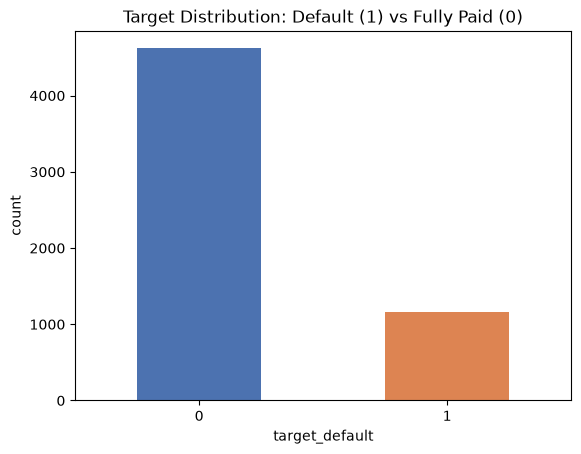

In [40]:
individual["target_default"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Target Distribution: Default (1) vs Fully Paid (0)")
plt.xlabel("target_default")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

## 9.2 Key Numeric Distributions — Individual Dataset

Histograms of the variables most likely to drive default risk.

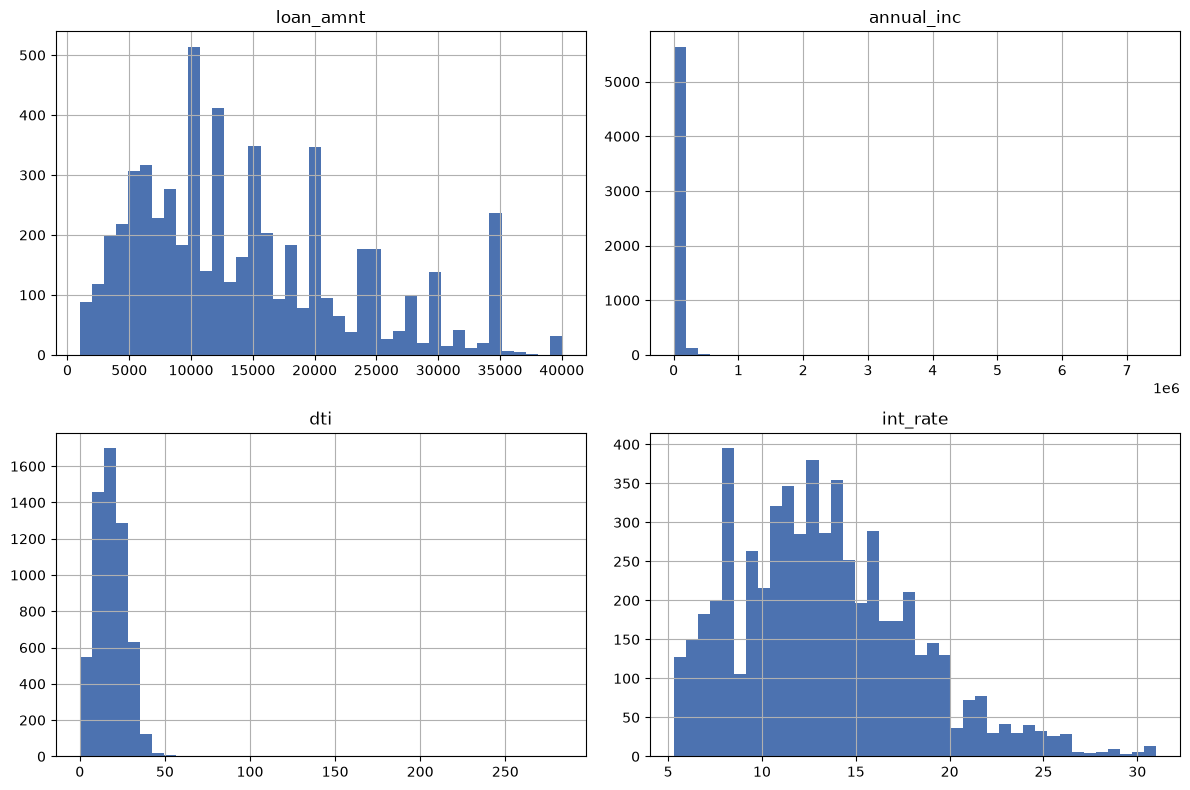

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ["loan_amnt", "annual_inc", "dti", "int_rate"]):
    individual[col].hist(bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 9.3 Feature vs Target — Boxplots

This is the actually useful view: does the distribution of a feature
shift between defaulters and non-defaulters?

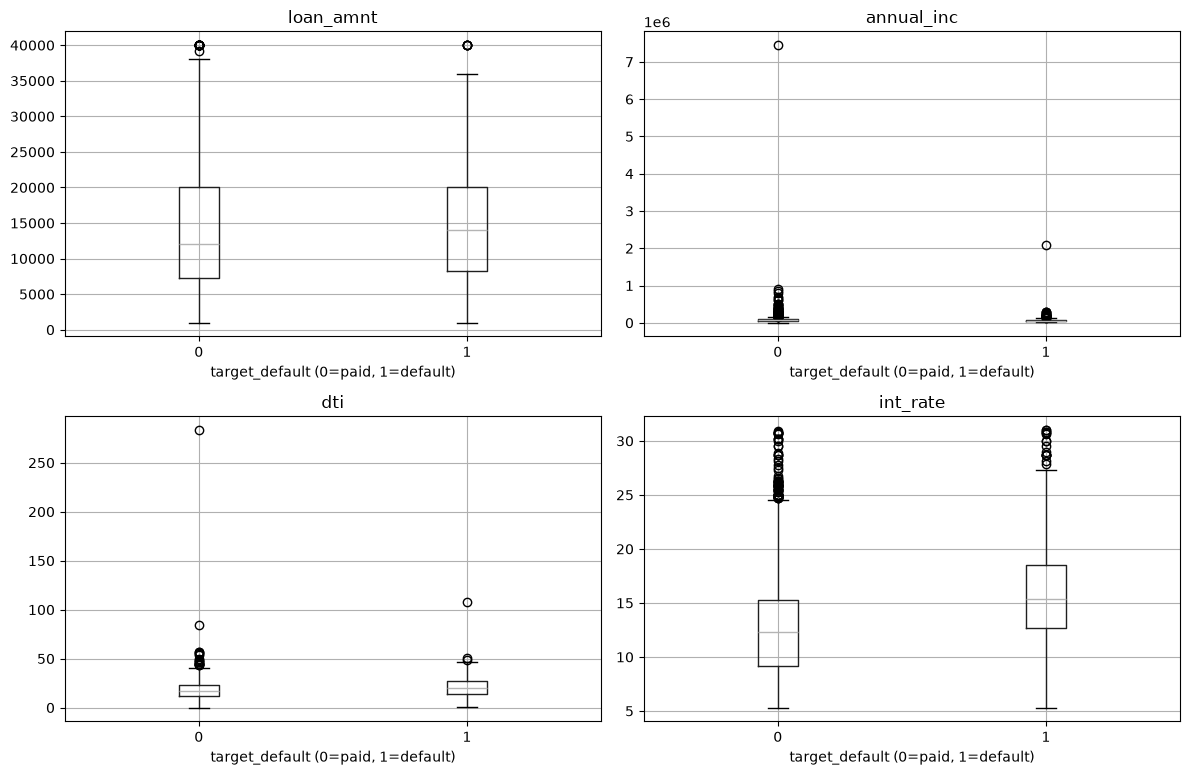

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ["loan_amnt", "annual_inc", "dti", "int_rate"]):
    individual.boxplot(column=col, by="target_default", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("target_default (0=paid, 1=default)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 9.4 Default Rate by Grade

LendingClub assigns each loan a letter grade (A–G) at origination based
on their own risk model. If our target behaves sensibly, default rate
should rise monotonically from A to G — that's a strong sanity check
on data integrity before we ever build a model.

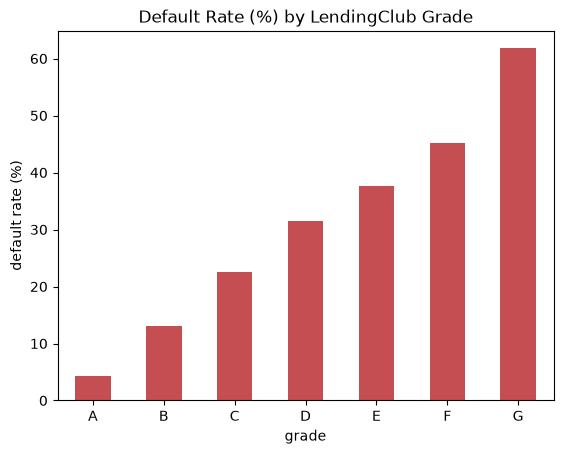

grade
A     4.253112
B    13.040865
C    22.539490
D    31.549610
E    37.704918
F    45.205479
G    61.764706
Name: target_default, dtype: float64


In [43]:
grade_default = individual.groupby("grade")["target_default"].mean().sort_index() * 100
grade_default.plot(kind="bar", color="#C44E52")
plt.title("Default Rate (%) by LendingClub Grade")
plt.ylabel("default rate (%)")
plt.xticks(rotation=0)
plt.show()
print(grade_default)

## 9.5 Correlation Heatmap — Individual Dataset

Restricted to a manageable set of numeric features, not all 124 columns.

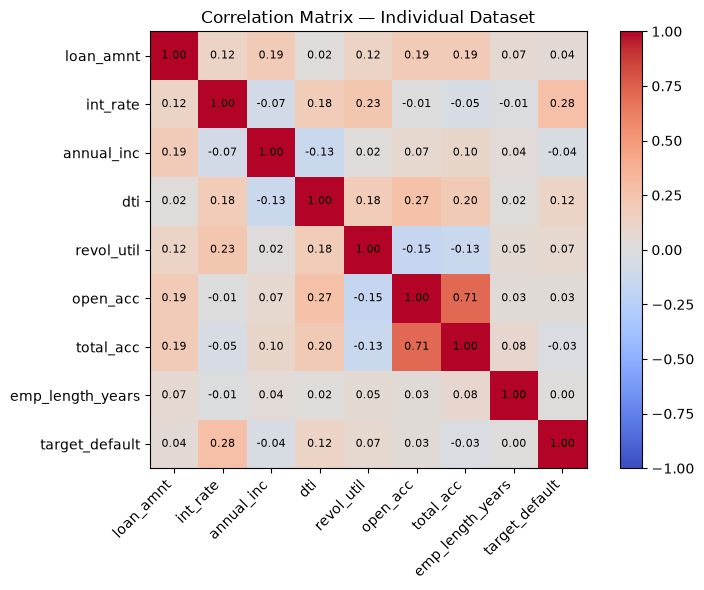

In [44]:
corr_cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "revol_util",
             "open_acc", "total_acc", "emp_length_years", "target_default"]
corr_matrix = individual[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix — Individual Dataset")
plt.tight_layout()
plt.show()

## 9.6 SME Dataset — Rating Distribution

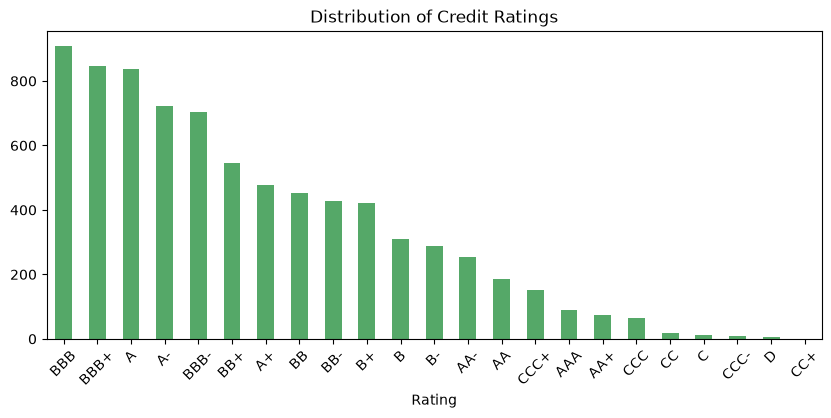

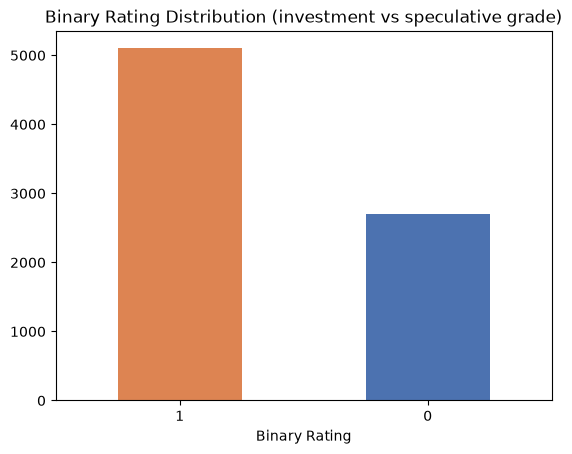

In [45]:
sme["Rating"].value_counts().plot(kind="bar", figsize=(10, 4), color="#55A868")
plt.title("Distribution of Credit Ratings")
plt.xticks(rotation=45)
plt.show()

sme["Binary Rating"].value_counts().plot(kind="bar", color=["#DD8452", "#4C72B0"])
plt.title("Binary Rating Distribution (investment vs speculative grade)")
plt.xticks(rotation=0)
plt.show()

## 9.7 SME Dataset — Ratios vs Binary Rating

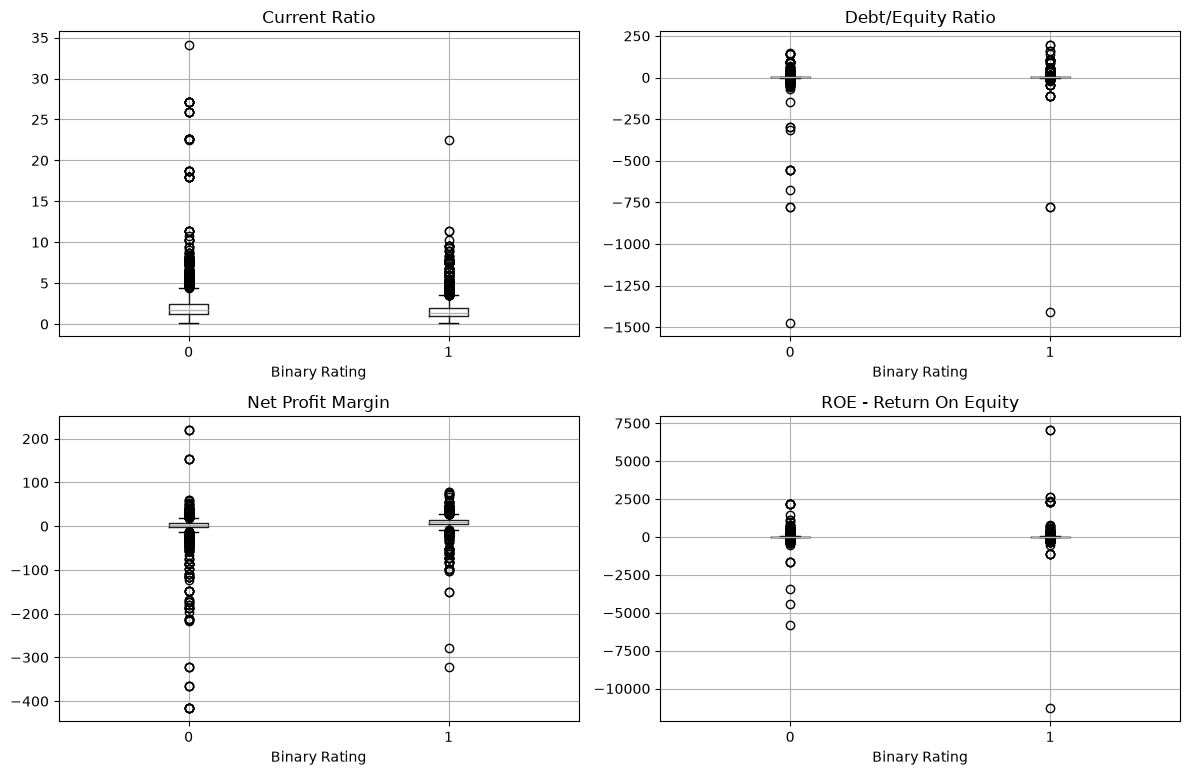

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ratio_cols = ["Current Ratio", "Debt/Equity Ratio", "Net Profit Margin", "ROE - Return On Equity"]
for ax, col in zip(axes.flatten(), ratio_cols):
    sme.boxplot(column=col, by="Binary Rating", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

## 9.8 Correlation Heatmap — SME Dataset

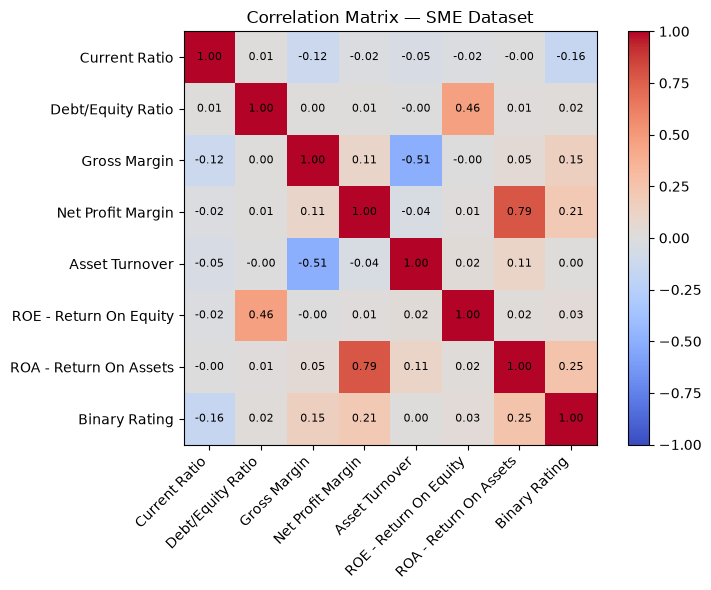

In [47]:
sme_corr_cols = ["Current Ratio", "Debt/Equity Ratio", "Gross Margin", "Net Profit Margin",
                  "Asset Turnover", "ROE - Return On Equity", "ROA - Return On Assets", "Binary Rating"]
sme_corr = sme[sme_corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sme_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(sme_corr_cols)))
ax.set_yticks(range(len(sme_corr_cols)))
ax.set_xticklabels(sme_corr_cols, rotation=45, ha="right")
ax.set_yticklabels(sme_corr_cols)
for i in range(len(sme_corr_cols)):
    for j in range(len(sme_corr_cols)):
        ax.text(j, i, f"{sme_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix — SME Dataset")
plt.tight_layout()
plt.show()

In [48]:
suspect_rows = individual[(individual["annual_inc"] > 1_000_000) | (individual["dti"] > 100)]
suspect_rows[["annual_inc", "dti", "loan_amnt", "grade", "target_default"]]

,annual_inc,dti,loan_amnt,grade,target_default
1235,7446395.0,0.13,20000,A,0
3214,2100000.0,0.48,14000,B,1
3437,47000.0,107.84,40000,C,1
4144,5000.0,283.17,15000,C,0


# Module 10 — Credit Risk Driver Report

## Individual Borrower Variables

### Loan Amount (loan_amnt)
The size of the requested loan. Larger loans carry more absolute dollar
risk if they default, but size alone doesn't predict default — it's
usually combined with income to judge affordability. Our EDA (Module 9)
showed a weak direct correlation with default (0.04), which makes sense:
a $30,000 loan to a high earner is safer than a $5,000 loan to someone
already stretched thin.

### Debt-To-Income Ratio (dti)
Total monthly debt payments divided by gross monthly income. This is one
of the single most important variables in consumer underwriting —
it directly measures how much financial slack a borrower has. A high
dti means a borrower is already committed elsewhere; any income
disruption (job loss, medical bill) has less room to absorb before
they miss a payment. Our EDA found a 0.12 correlation with default and
flagged two physically implausible outlier values to treat in Module 11.

### Credit Utilization (revol_util)
The percentage of available revolving credit (mainly credit cards)
currently being used. High utilization (e.g. maxed-out cards) is a
classic early warning sign in consumer credit — it signals a borrower
is relying on debt to cover expenses rather than using credit
occasionally. Showed the second-highest correlation with int_rate
(0.23) in our matrix, meaning LendingClub itself already prices risk
based on this heavily.

### Delinquencies (delinq_2yrs, acc_now_delinq)
Count of past-due accounts in the last two years / currently. This is
the strongest possible signal available: past delinquency is the
single best predictor of future delinquency in almost every consumer
credit model ever built ("past behavior predicts future behavior").
We haven't formally analyzed this yet — flagging it as a priority
feature for Module 11.

### Employment Length (emp_length_years)
Years at current job, converted to a number in Module 8. Longer
tenure signals income stability, which matters more than income level
alone — a stable $50k salary can be lower risk than a volatile $90k
one. Showed almost no direct correlation with default (0.00) in our
matrix, which is worth remembering: it may matter more in combination
with other features (e.g. self-employed + short tenure) than alone.

### Loan Status (loan_status)
NOT a predictive feature — this is the source of our target variable
(Module 8) and must never be used as a model input, since it only
exists because the loan already resolved. Listed here for completeness
of business understanding, not as something the model will see.


## SME Borrower Variables

### Current Ratio
Current assets / current liabilities — measures whether a company can
cover its short-term obligations with short-term assets. Below 1.0 is
a liquidity red flag (more owed soon than can be readily covered).
Showed a small negative correlation with Binary Rating (-0.16) in our
data — slightly counterintuitive, worth investigating further in
Module 11 rather than assuming it's wrong.

### Quick Ratio
NOT present in our dataset. This is the "acid-test" version of Current
Ratio — same idea but excludes inventory, since inventory isn't always
quickly convertible to cash. Noting its absence here as a known
limitation of this dataset versus a full commercial underwriting file.

### ROA — Return On Assets
Net income / total assets. Measures how efficiently a company turns
its total asset base into profit, independent of how that asset base
was financed (debt vs equity). Our strongest SME correlation with
Binary Rating (0.25) — the highest of any single ratio in the matrix,
making it a leading candidate feature for the SME model.

### ROE — Return On Equity
Net income / shareholder equity. Similar to ROA but measures return
specifically to equity holders — meaning it can be inflated by high
leverage (more debt makes equity smaller, which mechanically raises
ROE even if the business isn't more efficient). This is why ROE and
Debt/Equity showed a 0.46 correlation in our matrix — a company can
look more "profitable" on ROE alone purely by borrowing more, which is
exactly the kind of nuance a model (and an analyst) needs to be
careful about.

### Debt/Equity Ratio
Total debt divided by shareholder equity — the core leverage metric.
Higher means more of the company is financed by debt than by owners'
capital, which raises risk of default if cash flow tightens, since
debt payments are obligatory and equity returns are not.

### Interest Coverage Ratio
NOT present in our dataset. Normally EBIT / interest expense — measures
how many times over a company can pay its interest obligations from
operating earnings. A ratio below ~1.5 is a common warning threshold.
Noting its absence as another dataset limitation.

### EBITDA Margin
EBITDA / revenue — profitability before financing structure,
depreciation policy, and tax jurisdiction differences are factored in.
Useful for comparing companies of different sizes or capital
structures on a like-for-like operating basis.

### Asset Turnover
Revenue / total assets — how efficiently a company generates sales
from its asset base. Showed a notable -0.51 correlation with Gross
Margin in our matrix: businesses that turn assets over quickly (e.g.
retail) typically run on thinner margins than asset-light, high-margin
businesses (e.g. software) — a real structural relationship, not
a data issue.


## Known Data Limitations
Quick Ratio and Interest Coverage Ratio — two ratios a real commercial
underwriter would want — are not available in this dataset. This is a
genuine limitation worth stating explicitly in the final project
documentation (Module 23) rather than glossing over, since it affects
how complete the SME model's risk picture can be compared to a real
bank's internal model.

# Module 11 — Feature Engineering

**Objective:** Create business-meaningful features for both models,
explaining the rationale and expected predictive value of each.

In [49]:
individual_fe = pd.read_csv(processed_dir / "individual_clean.csv")
sme_fe = pd.read_csv(processed_dir / "sme_clean.csv")
individual_fe["issue_d"] = pd.to_datetime(individual_fe["issue_d"])
individual_fe["earliest_cr_line"] = pd.to_datetime(individual_fe["earliest_cr_line"])

## 11.1 Handle Flagged Outliers — Winsorizing, Not Deleting

Module 9 flagged extreme values in annual_inc and dti. Rather than
delete these rows (losing real, if unusual, data), we cap them at the
1st/99th percentile — a technique called winsorizing. This keeps every
row while preventing a handful of extreme values from distorting
scaling and model training later.

In [50]:
def winsorize(series, lower_pct=0.01, upper_pct=0.99):
    lower, upper = series.quantile(lower_pct), series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

print("Before capping:")
print(individual_fe[["annual_inc", "dti"]].describe())

individual_fe["annual_inc"] = winsorize(individual_fe["annual_inc"])
individual_fe["dti"] = winsorize(individual_fe["dti"])

print("\nAfter capping:")
print(individual_fe[["annual_inc", "dti"]].describe())

Before capping:
         annual_inc          dti
count  5.778000e+03  5778.000000
mean   7.725693e+04    18.317901
std    1.125636e+05     9.469482
min    5.000000e+03     0.000000
25%    4.500000e+04    11.722500
50%    6.500000e+04    17.645000
75%    9.176250e+04    24.305000
max    7.446395e+06   283.170000

After capping:
          annual_inc          dti
count    5778.000000  5778.000000
mean    74520.419683    18.217252
std     41836.103130     8.545505
min     18000.000000     1.707700
25%     45000.000000    11.722500
50%     65000.000000    17.645000
75%     91762.500000    24.305000
max    250000.000000    38.612300


## 11.2 Affordability Features

**loan_to_income:** loan_amnt / annual_inc — how large the loan is
relative to what the borrower earns in a year. More direct than dti,
which only looks at monthly debt vs monthly income, not the loan size
itself. Expected to be a strong predictor: a $30k loan against $200k
income is a very different risk than the same loan against $35k income.

**installment_to_income:** monthly payment (installment) / monthly
income — the most direct affordability check of all: can this specific
payment realistically fit in this specific budget every month?

In [51]:
import pandas as pd

new_feats = pd.DataFrame({
    "loan_to_income": individual_fe["loan_amnt"] / individual_fe["annual_inc"],
    "installment_to_income": individual_fe["installment"] / (individual_fe["annual_inc"] / 12),
}, index=individual_fe.index)

individual_fe = pd.concat([individual_fe, new_feats], axis=1)

individual_fe[["loan_to_income", "installment_to_income"]].describe()

,loan_to_income,installment_to_income
count,5778.000000,5778.000000
mean,0.214529,0.079259
std,0.118126,0.044083
min,0.008333,0.003517
25%,0.123130,0.046278
50%,0.200000,0.071466
75%,0.292831,0.106962
max,1.028571,0.386813


## 11.3 Delinquency & Derogatory History Features

Module 10 flagged this as the highest-priority gap: past delinquency
behavior is typically the single strongest predictor in consumer
credit models. We combine several raw signals into one composite score
and one recency flag.

In [52]:
# Composite count of all negative credit events on file
derog_cols = ["delinq_2yrs", "pub_rec", "collections_12_mths_ex_med", "acc_now_delinq"]
for col in derog_cols:
    individual_fe[col] = individual_fe[col].fillna(0)

individual_fe["total_derogatory_events"] = individual_fe[derog_cols].sum(axis=1)

# Recency flag: was there a delinquency in the last 24 months, specifically?
individual_fe["recent_delinquency_flag"] = (individual_fe["delinq_2yrs"] > 0).astype(int)

print(individual_fe["total_derogatory_events"].value_counts().sort_index().head(10))
print(f"\nRecent delinquency rate: {individual_fe['recent_delinquency_flag'].mean()*100:.2f}%")

# Quick check: does this actually relate to our target?
print("\nDefault rate by recent delinquency flag:")
print(individual_fe.groupby("recent_delinquency_flag")["target_default"].mean() * 100)


total_derogatory_events
0.0    3781
1.0    1350
2.0     362
3.0     152
4.0      62
5.0      34
6.0      10
7.0       9
8.0       4
9.0       6
Name: count, dtype: int64

Recent delinquency rate: 19.37%

Default rate by recent delinquency flag:
recent_delinquency_flag
0    19.918437
1    20.732797
Name: target_default, dtype: float64


C:\Users\pc\AppData\Local\Temp\ipykernel_25736\2689023518.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  individual_fe["total_derogatory_events"] = individual_fe[derog_cols].sum(axis=1)
C:\Users\pc\AppData\Local\Temp\ipykernel_25736\2689023518.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  individual_fe["recent_delinquency_flag"] = (individual_fe["delinq_2yrs"] > 0).astype(int)


## 11.4 Credit History Length

Years between the borrower's earliest credit line and this loan's
issue date. Longer credit history generally means more established,
more predictable credit behavior — lenders have simply had more time
to observe how this person handles credit.

In [53]:
individual_fe["credit_history_years"] = (
    (individual_fe["issue_d"] - individual_fe["earliest_cr_line"]).dt.days / 365.25
)
individual_fe["credit_history_years"].describe()

C:\Users\pc\AppData\Local\Temp\ipykernel_25736\2870022428.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  individual_fe["credit_history_years"] = (


count    5777.000000
mean       16.403357
std         7.722406
min         3.085558
25%        11.329227
50%        14.830938
75%        19.917864
max        56.418891
Name: credit_history_years, dtype: float64

## 11.5 Credit Utilization Risk Tier

Rather than only using revol_util as a raw number, bucket it into
tiers that mirror how underwriters actually think about it: low, oksh,
high, maxed. Tree-based models (Module 15) can find non-linear splits
on their own, but an explicit tier is more interpretable in SHAP
explanations later (Module 17) — which matters since interpretability
is part of this project's deliverable.

In [54]:
def utilization_tier(x):
    if pd.isna(x):
        return "unknown"
    elif x < 30:
        return "low"
    elif x < 60:
        return "moderate"
    elif x < 90:
        return "high"
    else:
        return "maxed"

individual_fe["utilization_tier"] = individual_fe["revol_util"].apply(utilization_tier)
individual_fe["utilization_tier"].value_counts()

C:\Users\pc\AppData\Local\Temp\ipykernel_25736\193289350.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  individual_fe["utilization_tier"] = individual_fe["revol_util"].apply(utilization_tier)


utilization_tier
moderate    2297
high        1903
low         1198
maxed        377
unknown        3
Name: count, dtype: int64

## 11.6 SME Dataset — Profitability Consistency

**margin_spread:** Gross Margin minus Net Profit Margin — the gap
between what a company keeps after production costs versus what it
keeps after ALL costs (operating, interest, tax). A wide spread means
heavy non-production costs (debt service, overhead) are eating into
profit even though the core business is fine — a different risk story
than a company with weak gross margin to begin with.

In [55]:
sme_fe["margin_spread"] = sme_fe["Gross Margin"] - sme_fe["Net Profit Margin"]
sme_fe[["Gross Margin", "Net Profit Margin", "margin_spread"]].describe()

,Gross Margin,Net Profit Margin,margin_spread
count,7805.000000,7805.000000,7805.000000
mean,42.433909,5.995566,36.438343
std,23.742020,24.055577,31.901180
min,-87.684000,-414.824800,-152.723600
25%,22.453900,2.637100,17.308800
50%,39.635400,6.938900,31.816500
75%,59.641700,12.366700,48.031700
max,100.000000,219.390300,486.818500


## 11.7 SME Dataset — Leverage-Adjusted Return Flag

Module 10 noted ROE can be inflated by leverage rather than genuine
efficiency (0.46 correlation with Debt/Equity in our matrix). We add a
flag for companies with high ROE AND high leverage simultaneously —
the combination that should raise scrutiny, versus high ROE alone
which may be a genuinely well-run company.

In [56]:
high_roe = sme_fe["ROE - Return On Equity"] > sme_fe["ROE - Return On Equity"].quantile(0.75)
high_leverage = sme_fe["Debt/Equity Ratio"] > sme_fe["Debt/Equity Ratio"].quantile(0.75)

sme_fe["leverage_driven_returns_flag"] = (high_roe & high_leverage).astype(int)
print(sme_fe["leverage_driven_returns_flag"].value_counts())
print("\nBinary Rating rate by flag:")
print(sme_fe.groupby("leverage_driven_returns_flag")["Binary Rating"].mean())

leverage_driven_returns_flag
0    6992
1     813
Name: count, dtype: int64

Binary Rating rate by flag:
leverage_driven_returns_flag
0    0.653032
1    0.655597
Name: Binary Rating, dtype: float64


## 11.8 Save Feature-Engineered Datasets

In [57]:
individual_fe.to_csv(processed_dir / "individual_features.csv", index=False)
sme_fe.to_csv(processed_dir / "sme_features.csv", index=False)

print(f"individual_features saved: {individual_fe.shape}")
print(f"sme_features saved: {sme_fe.shape}")

individual_features saved: (5778, 130)
sme_features saved: (7805, 27)


############# fix

In [58]:
missing_history = individual_fe[individual_fe["credit_history_years"].isna()]
missing_history[["issue_d", "earliest_cr_line", "credit_history_years"]]

,issue_d,earliest_cr_line,credit_history_years
5776,2007-06-01,NaT,NaN


In [59]:
# Find this same row in the pre-conversion data to see the raw, unparsed value
raw_row = individual_df.loc[individual_df["issue_d"] == "Jun-2007", "earliest_cr_line"]
print(raw_row)

7867    NaN
Name: earliest_cr_line, dtype: str


In [60]:
# Impute this one row's credit history with the dataset median,
# rather than drop a row we're already short on
median_history = individual_fe["credit_history_years"].median()
individual_fe["credit_history_years"] = individual_fe["credit_history_years"].fillna(median_history)

print(f"Imputed missing value with median: {median_history:.2f} years")
print(individual_fe["credit_history_years"].isna().sum(), "missing values remain")

# Re-save with the fix
individual_fe.to_csv(processed_dir / "individual_features.csv", index=False)
print("Re-saved individual_features.csv")

Imputed missing value with median: 14.83 years
0 missing values remain
Re-saved individual_features.csv


In [61]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt

plt.figure()
plt.plot([1,2,3],[1,4,9])
plt.savefig("test.png")

print("Success")

Success
